In [48]:
import pandas as pd 
import torch 
from torch import nn 
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt 
from utils import train_and_test_loop, plot_decision_boundary

### Load Dataset (binary_classification_moons.csv)

In [49]:
# Load Dataset
df = pd.read_csv("../dataset/binary_classification_moons.csv")

print(df.head())

         X1        X2  label
0 -0.009332  0.390981      1
1  0.954574 -0.473756      1
2  0.918526 -0.425196      1
3  0.412768 -0.376385      1
4 -0.845320  0.528799      0


In [50]:
# vectorizing X1 and X2 into a single tensor/nparray

X = df[['X1', 'X2']].values
y = df['label'].values

In [51]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [52]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

device

'cpu'

## Model 1: LinearRegressionNN (from Task 1)
First, let's test the LinearRegressionNN model from Task 1 on this binary classification dataset.

In [53]:
# LinearRegressionNN adapted for binary classification (2 input features)
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=2,  # Changed from 1 to 2 for X1, X2
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

model_lr = LinearRegressionNN().to(device)
print(model_lr)

LinearRegressionNN(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)


Epoch: 0 | Loss: 0.71668, Accuracy: 38.00% | Test loss: 0.71545, Test acc: 37.00%
Epoch: 10 | Loss: 0.63287, Accuracy: 56.62% | Test loss: 0.64138, Test acc: 53.50%
Epoch: 20 | Loss: 0.57484, Accuracy: 66.75% | Test loss: 0.58960, Test acc: 61.50%
Epoch: 30 | Loss: 0.53246, Accuracy: 71.62% | Test loss: 0.55129, Test acc: 66.50%
Epoch: 40 | Loss: 0.50016, Accuracy: 74.50% | Test loss: 0.52167, Test acc: 68.00%
Epoch: 50 | Loss: 0.47472, Accuracy: 76.25% | Test loss: 0.49798, Test acc: 69.00%
Epoch: 60 | Loss: 0.45414, Accuracy: 77.50% | Test loss: 0.47854, Test acc: 71.50%
Epoch: 70 | Loss: 0.43713, Accuracy: 78.12% | Test loss: 0.46224, Test acc: 73.50%
Epoch: 80 | Loss: 0.42282, Accuracy: 78.75% | Test loss: 0.44834, Test acc: 74.00%
Epoch: 90 | Loss: 0.41060, Accuracy: 79.50% | Test loss: 0.43632, Test acc: 74.50%
Epoch: 100 | Loss: 0.40003, Accuracy: 80.00% | Test loss: 0.42578, Test acc: 75.50%
Epoch: 110 | Loss: 0.39077, Accuracy: 80.62% | Test loss: 0.41645, Test acc: 76.00%
Epo

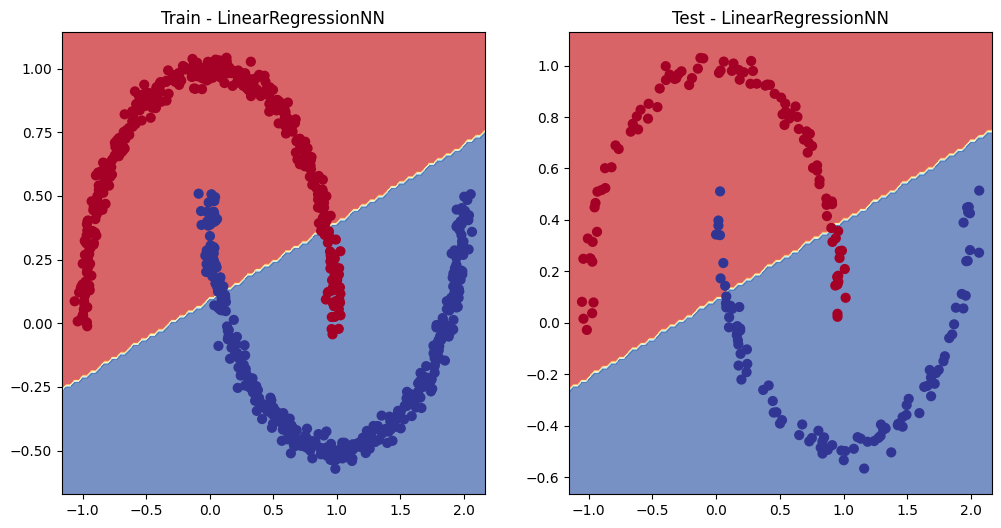

In [54]:
# Train LinearRegressionNN
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_lr.parameters(), lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model_lr,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - LinearRegressionNN")
plot_decision_boundary(model_lr, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - LinearRegressionNN")
plot_decision_boundary(model_lr, X_test, y_test)

## Model 2: ModelV0 (Linear layers without activation)

In [55]:
# ModelV0 - Linear layers without activation
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

model_v0 = ModelV0().to(device)
print(model_v0)

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)


Epoch: 0 | Loss: 0.75568, Accuracy: 57.25% | Test loss: 0.72078, Test acc: 62.00%
Epoch: 10 | Loss: 0.66546, Accuracy: 67.62% | Test loss: 0.64774, Test acc: 73.00%
Epoch: 20 | Loss: 0.60099, Accuracy: 77.12% | Test loss: 0.58990, Test acc: 78.50%
Epoch: 30 | Loss: 0.53056, Accuracy: 85.50% | Test loss: 0.52490, Test acc: 84.50%
Epoch: 40 | Loss: 0.45801, Accuracy: 88.25% | Test loss: 0.45841, Test acc: 89.00%
Epoch: 50 | Loss: 0.39615, Accuracy: 87.38% | Test loss: 0.40231, Test acc: 88.50%
Epoch: 60 | Loss: 0.35162, Accuracy: 86.75% | Test loss: 0.36180, Test acc: 88.00%
Epoch: 70 | Loss: 0.32227, Accuracy: 86.50% | Test loss: 0.33450, Test acc: 88.00%
Epoch: 80 | Loss: 0.30318, Accuracy: 86.62% | Test loss: 0.31607, Test acc: 87.50%
Epoch: 90 | Loss: 0.29038, Accuracy: 86.50% | Test loss: 0.30311, Test acc: 87.50%
Epoch: 100 | Loss: 0.28138, Accuracy: 86.50% | Test loss: 0.29352, Test acc: 87.50%
Epoch: 110 | Loss: 0.27471, Accuracy: 86.75% | Test loss: 0.28606, Test acc: 87.50%
Epo

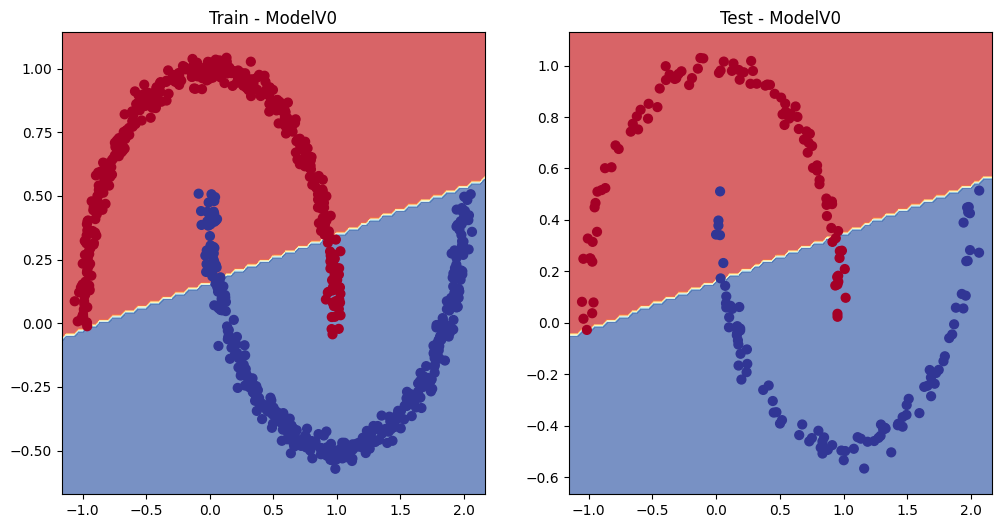

In [56]:
# Train ModelV0
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v0.parameters(), lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model_v0,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - ModelV0")
plot_decision_boundary(model_v0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - ModelV0")
plot_decision_boundary(model_v0, X_test, y_test)

## Model 3: ModelV1 (With ReLU activation, fewer hidden units)

In [57]:
# ModelV1 - With ReLU activation, fewer hidden units
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_2(self.relu(self.layer_1(x)))

model_v1 = ModelV1().to(device)
print(model_v1)

ModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)


Epoch: 0 | Loss: 0.68942, Accuracy: 56.00% | Test loss: 0.69142, Test acc: 48.00%
Epoch: 10 | Loss: 0.68326, Accuracy: 52.62% | Test loss: 0.68673, Test acc: 49.50%
Epoch: 20 | Loss: 0.67644, Accuracy: 56.00% | Test loss: 0.68132, Test acc: 50.50%
Epoch: 30 | Loss: 0.66813, Accuracy: 58.63% | Test loss: 0.67446, Test acc: 53.50%
Epoch: 40 | Loss: 0.65771, Accuracy: 60.62% | Test loss: 0.66554, Test acc: 57.50%
Epoch: 50 | Loss: 0.64481, Accuracy: 63.25% | Test loss: 0.65420, Test acc: 61.00%
Epoch: 60 | Loss: 0.62927, Accuracy: 66.25% | Test loss: 0.64024, Test acc: 64.00%
Epoch: 70 | Loss: 0.61120, Accuracy: 68.50% | Test loss: 0.62370, Test acc: 66.50%
Epoch: 80 | Loss: 0.59098, Accuracy: 71.12% | Test loss: 0.60491, Test acc: 69.00%
Epoch: 90 | Loss: 0.56925, Accuracy: 73.25% | Test loss: 0.58440, Test acc: 70.00%
Epoch: 100 | Loss: 0.54666, Accuracy: 75.62% | Test loss: 0.56284, Test acc: 72.00%
Epoch: 110 | Loss: 0.52385, Accuracy: 76.88% | Test loss: 0.54072, Test acc: 74.00%
Epo

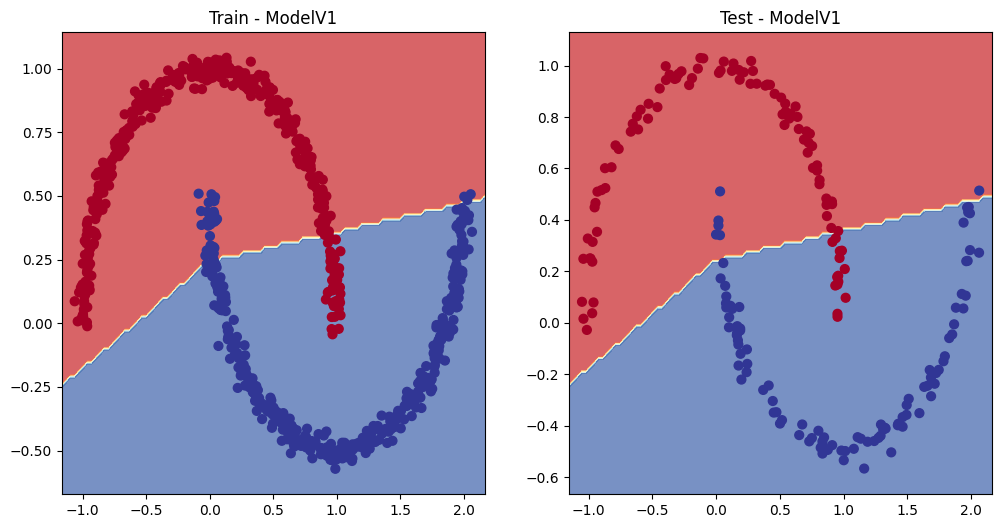

In [58]:
# Train ModelV1
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v1.parameters(), lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model_v1,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - ModelV1")
plot_decision_boundary(model_v1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - ModelV1")
plot_decision_boundary(model_v1, X_test, y_test)

## Model 4: ModelV3 (More layers and hidden units)

In [59]:
# ModelV3 - More layers and hidden units
class ModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=20)
        self.layer_4 = nn.Linear(in_features=20, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_4(self.relu(self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))))

model_v3 = ModelV3().to(device)
print(model_v3)

ModelV3(
  (layer_1): Linear(in_features=2, out_features=20, bias=True)
  (layer_2): Linear(in_features=20, out_features=20, bias=True)
  (layer_3): Linear(in_features=20, out_features=20, bias=True)
  (layer_4): Linear(in_features=20, out_features=1, bias=True)
  (relu): ReLU()
)


Epoch: 0 | Loss: 0.69258, Accuracy: 50.00% | Test loss: 0.69267, Test acc: 50.00%
Epoch: 10 | Loss: 0.68824, Accuracy: 50.00% | Test loss: 0.68862, Test acc: 50.00%
Epoch: 20 | Loss: 0.68406, Accuracy: 67.12% | Test loss: 0.68484, Test acc: 64.00%
Epoch: 30 | Loss: 0.67999, Accuracy: 73.50% | Test loss: 0.68106, Test acc: 71.00%
Epoch: 40 | Loss: 0.67455, Accuracy: 78.50% | Test loss: 0.67600, Test acc: 73.50%
Epoch: 50 | Loss: 0.66681, Accuracy: 79.38% | Test loss: 0.66883, Test acc: 76.00%
Epoch: 60 | Loss: 0.65552, Accuracy: 80.00% | Test loss: 0.65842, Test acc: 76.00%
Epoch: 70 | Loss: 0.63975, Accuracy: 80.38% | Test loss: 0.64367, Test acc: 76.50%
Epoch: 80 | Loss: 0.61641, Accuracy: 80.75% | Test loss: 0.62157, Test acc: 78.00%
Epoch: 90 | Loss: 0.58108, Accuracy: 81.00% | Test loss: 0.58755, Test acc: 80.50%
Epoch: 100 | Loss: 0.52999, Accuracy: 81.75% | Test loss: 0.53869, Test acc: 81.00%
Epoch: 110 | Loss: 0.46930, Accuracy: 82.50% | Test loss: 0.48065, Test acc: 82.50%
Epo

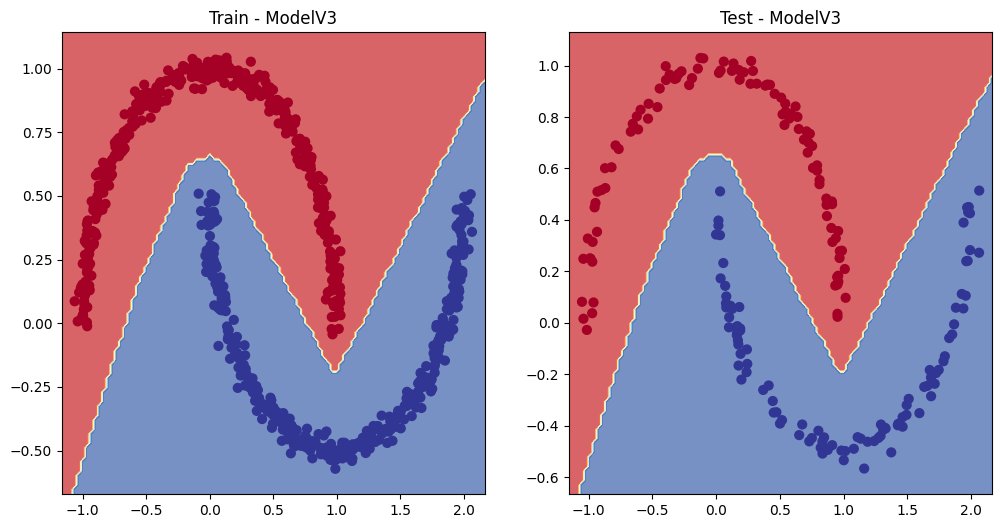

In [60]:
# Train ModelV3
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_v3.parameters(), lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model_v3,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - ModelV3")
plot_decision_boundary(model_v3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - ModelV3")
plot_decision_boundary(model_v3, X_test, y_test)

In [61]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [62]:
from utils import train_and_test_loop, plot_decision_boundary
import matplotlib.pyplot as plt

Epoch: 0 | Loss: 0.73100, Accuracy: 50.00% | Test loss: 0.72078, Test acc: 50.00%
Epoch: 10 | Loss: 0.66154, Accuracy: 69.88% | Test loss: 0.65947, Test acc: 73.50%
Epoch: 20 | Loss: 0.60533, Accuracy: 81.25% | Test loss: 0.60645, Test acc: 78.50%
Epoch: 30 | Loss: 0.54494, Accuracy: 81.75% | Test loss: 0.54978, Test acc: 77.50%
Epoch: 40 | Loss: 0.48289, Accuracy: 82.25% | Test loss: 0.49145, Test acc: 78.00%
Epoch: 50 | Loss: 0.42758, Accuracy: 82.50% | Test loss: 0.43948, Test acc: 80.50%
Epoch: 60 | Loss: 0.38539, Accuracy: 83.12% | Test loss: 0.39946, Test acc: 81.50%
Epoch: 70 | Loss: 0.35554, Accuracy: 83.25% | Test loss: 0.37014, Test acc: 81.50%
Epoch: 80 | Loss: 0.33402, Accuracy: 83.62% | Test loss: 0.34779, Test acc: 82.50%
Epoch: 90 | Loss: 0.31715, Accuracy: 84.00% | Test loss: 0.32953, Test acc: 83.50%


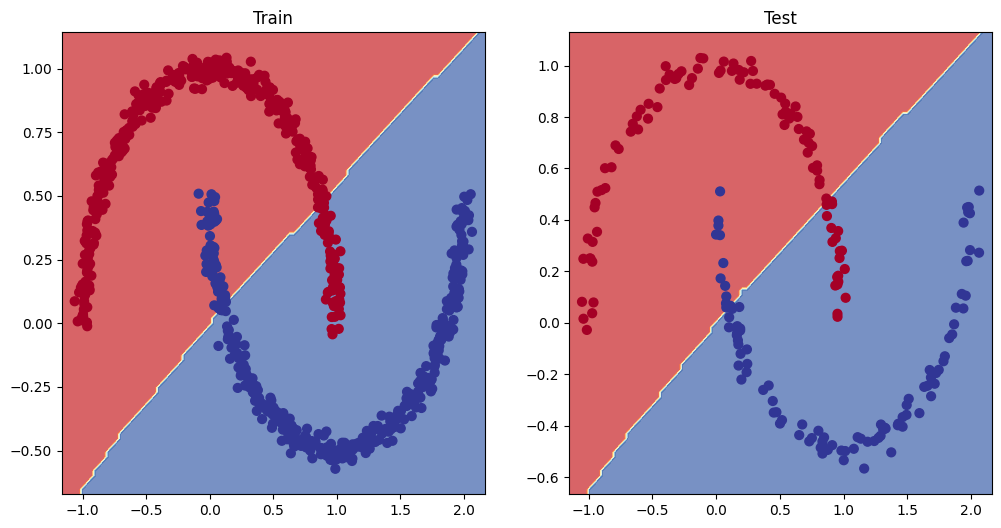

In [63]:
model = model_2
epochs = 100

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

Epoch: 0 | Loss: 0.70637, Accuracy: 50.00% | Test loss: 0.69897, Test acc: 50.00%
Epoch: 10 | Loss: 0.66350, Accuracy: 82.12% | Test loss: 0.66048, Test acc: 81.50%
Epoch: 20 | Loss: 0.62694, Accuracy: 81.62% | Test loss: 0.62698, Test acc: 77.50%
Epoch: 30 | Loss: 0.58793, Accuracy: 80.75% | Test loss: 0.59084, Test acc: 77.00%
Epoch: 40 | Loss: 0.54251, Accuracy: 80.50% | Test loss: 0.54892, Test acc: 78.00%
Epoch: 50 | Loss: 0.49362, Accuracy: 80.75% | Test loss: 0.50406, Test acc: 78.50%
Epoch: 60 | Loss: 0.44662, Accuracy: 81.25% | Test loss: 0.46036, Test acc: 79.00%
Epoch: 70 | Loss: 0.40585, Accuracy: 82.00% | Test loss: 0.42164, Test acc: 79.50%
Epoch: 80 | Loss: 0.37275, Accuracy: 82.50% | Test loss: 0.38908, Test acc: 80.50%
Epoch: 90 | Loss: 0.34659, Accuracy: 83.38% | Test loss: 0.36209, Test acc: 81.50%
Epoch: 100 | Loss: 0.32552, Accuracy: 84.75% | Test loss: 0.33958, Test acc: 83.00%
Epoch: 110 | Loss: 0.30828, Accuracy: 85.00% | Test loss: 0.32051, Test acc: 84.50%
Epo

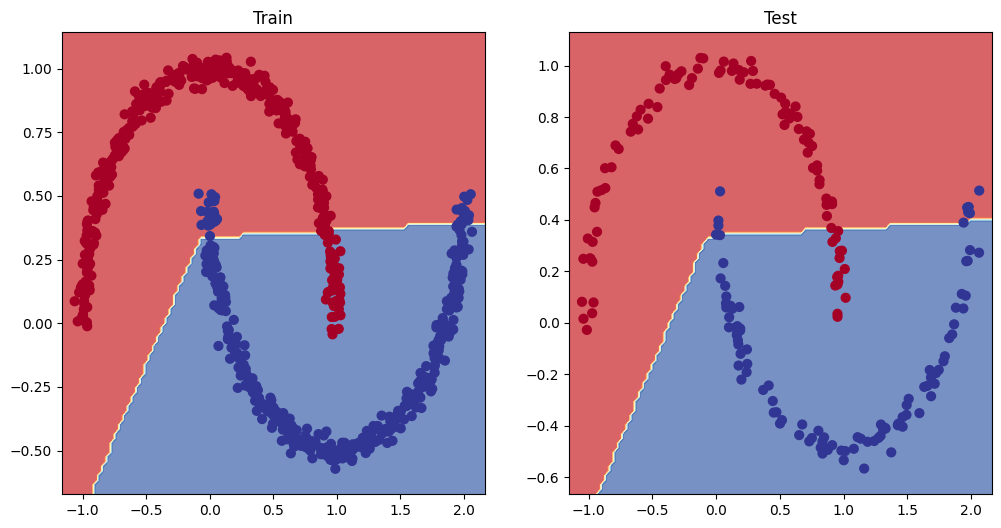

In [64]:
epochs = 1000
model = ModelV2().to(device) # reset model
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

#### Results
LinearRegressionNN
- Suitable for linear regression datasets only.
- Not suitable for the moons dataset.

#### ModelV0
- Accepts two features.
- Contains only linear transformations.
- Unable to learn nonlinear boundaries.
- Not suitable for the moons dataset.

#### ModelV2
- Uses hidden layers and ReLU activation.
- Learns nonlinear patterns.
- Achieved significantly higher accuracy than random guessing.
- Produced curved decision boundaries matching the moons dataset.
